# **Deep Learning Project**
# ***Predicting if a bank customer will exit the bank***

### Importing the libraries

In [31]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import wandb
import os
import json

from sklearn.metrics import classification_report, roc_curve, confusion_matrix
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from wandb.integration.keras import WandbMetricsLogger

### Login to W&B

In [2]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: k-motealehi (arminfakhar1384-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Importing the dataset

In [3]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [4]:
#print(X)
#print(y)

## **Data preprocessing**

### Splitting the data into train & test

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [6]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography  & gender column

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [8]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Seperating the validation set**

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# print("Train split:", X_tr.shape, y_tr.shape)
# print("Val split:", X_val.shape, y_val.shape)

## **Building the Nerual Network**

A feedforward neural network is constructed with:

*   Two hidden layers (both 6 neurons) using ReLU activation function.
*   One output layer with Sigmoid activation function for binary classification.

ReLU is used to introduce non-linearity, while Sigmoid outputs probabilities between 0 and 1.

### Initializing the ANN

In [10]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [11]:
model.add(tf.keras.layers.Dense(6, activation="relu", input_shape=(X_train.shape[1],)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Adding the second hidden layer

In [12]:
model.add(tf.keras.layers.Dense(6, activation="relu"))

### Adding the output layer

In [13]:
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

### Handling Class Imbalance

In this step, we address the class imbalance problem by applying **class weights** technique:

We calculate class weights to give higher importance to the minority class (churn), ensuring the model doesn't ignore churn customers.

it will help improve recall for the churn class.


In [14]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
class_weight_dict = dict(zip(np.unique(y_tr), class_weights))

print("Class Weights:", class_weight_dict)

Class Weights: {np.int64(0): np.float64(0.6279434850863422), np.int64(1): np.float64(2.4539877300613497)}


## **Training the ANN**


### Compiling the ANN

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

### Callbacks - Saving checkpoint


In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Experiment Tracking with Weights & Biases (W&B)

In [17]:
RUN_NAME = "model_2_exp_4"

wandb.init(
    entity="arminfakhar1384-",
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 24,
        "architecture": "6-6-relu + sigmoid",
        "epochs": 100,
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "class_weight": "balanced"
    }
)

wandb_callback = WandbMetricsLogger()

### Training the ANN on the Training set

The model is trained for up to 100 epochs with a batch size of 32.
A validation split is used to monitor generalization performance during training.

In [18]:
history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val), # we seperate val_datas
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, wandb_callback],
    verbose=1
)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4449 - auc: 0.5297 - loss: 0.6955 - precision: 0.2125 - recall: 0.6305 - val_accuracy: 0.6463 - val_auc: 0.6405 - val_loss: 0.6779 - val_precision: 0.3020 - val_recall: 0.5613
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6112 - auc: 0.6448 - loss: 0.6719 - precision: 0.2863 - recall: 0.5729 - val_accuracy: 0.6781 - val_auc: 0.7051 - val_loss: 0.6401 - val_precision: 0.3345 - val_recall: 0.5859
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6703 - auc: 0.7113 - loss: 0.6285 - precision: 0.3276 - recall: 0.6060 - val_accuracy: 0.6850 - val_auc: 0.7411 - val_loss: 0.6234 - val_precision: 0.3536 - val_recall: 0.6595
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6921 - auc: 0.7473 - loss: 0.5990 - precision: 0.3554 - recall: 0.6287 - val_accuracy: 0.7269 - val_auc: 0.7552 - val_loss: 0.5821 - val_precision: 0.3935 - val_recall: 0.6288
Epoch 5/100
200/200 ━━━━━━━━

### Find best threshold

In [19]:
val_probs = model.predict(X_val).ravel()

thresholds = np.linspace(0.01, 0.99, 99)
f1s, precs, recs = [], [], []

for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    f1s.append(f1_score(y_val, val_pred))                 # binary F1 (class 1)
    precs.append(precision_score(y_val, val_pred, zero_division=0))
    recs.append(recall_score(y_val, val_pred, zero_division=0))

best_idx = int(np.argmax(f1s))
best_t = float(thresholds[best_idx])

print("Best threshold (val):", best_t)
print("Val F1:", f1s[best_idx])
print("Val Precision:", precs[best_idx])
print("Val Recall:", recs[best_idx])


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best threshold (val): 0.65
Val F1: 0.582089552238806
Val Precision: 0.5668604651162791
Val Recall: 0.598159509202454


#### Visualizing:

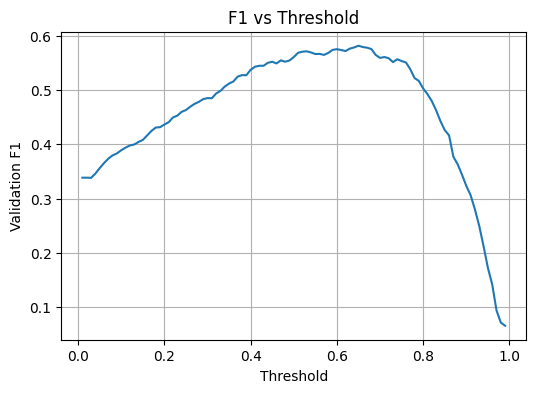

In [20]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, f1s)
plt.xlabel("Threshold")
plt.ylabel("Validation F1")
plt.title("F1 vs Threshold")
plt.grid(True)
plt.show()


### Performance Visualization - Training and Validation Curves


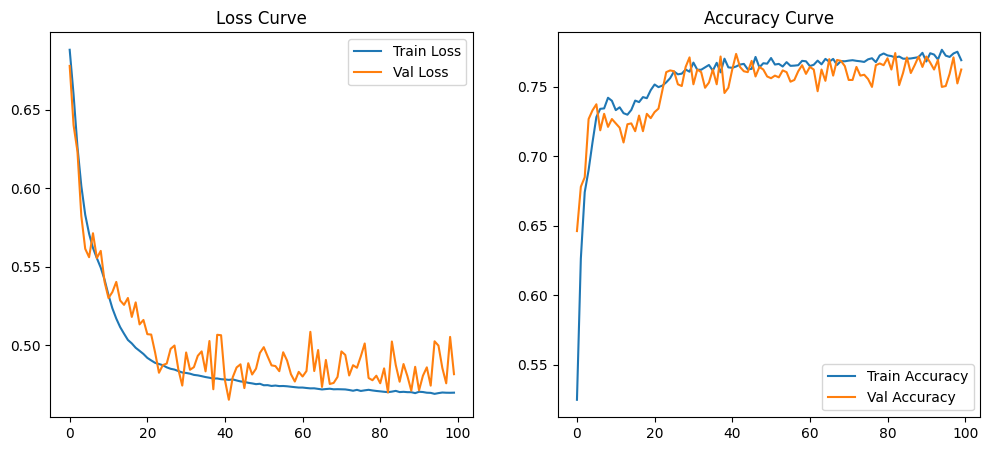

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

## **Predicting and evaluating the model**

### Confusion Matrix Analysis

In [22]:
test_probs = model.predict(X_test).ravel()
test_pred = (test_probs >= best_t).astype(int)

print("Using threshold:", best_t)
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Using threshold: 0.65
Confusion Matrix:
 [[1411  182]
 [ 155  252]]


**Performance metrics** such as Accuracy, Precision, Recall, F1-score, and AUC are calculated to assess generalization ability.

In [23]:
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred, digits=4))

print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))


Classification Report:

              precision    recall  f1-score   support

           0     0.9010    0.8858    0.8933      1593
           1     0.5806    0.6192    0.5993       407

    accuracy                         0.8315      2000
   macro avg     0.7408    0.7525    0.7463      2000
weighted avg     0.8358    0.8315    0.8335      2000

Test ROC-AUC: 0.8513675462828005


### Plotting ROC Curve

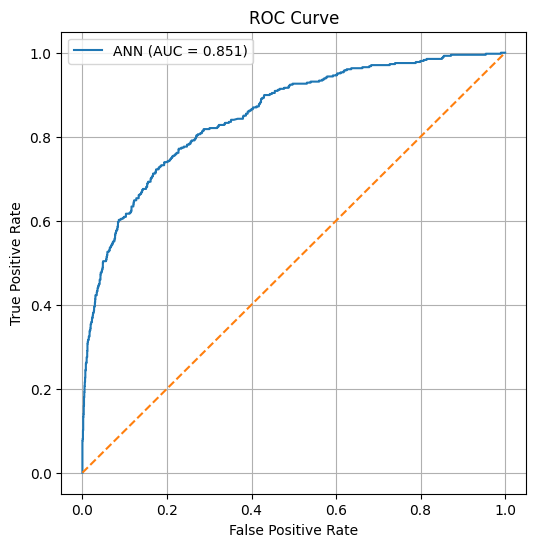

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


### Attach predictions to test DataFrame

In [25]:
test_results = pd.DataFrame(X_test)
test_results["true_label"] = y_test
test_results["pred_label"] = test_pred
test_results["pred_prob"]  = test_probs

print("Test results table created.")
test_results.head()


Test results table created.


,0,1,2,3,4,5,6,7,8,9,10,11,12,true_label,pred_label,pred_prob
0,0.947145,-0.557907,-0.555018,-0.867668,0.867668,-0.694450,-0.277326,0.705175,-1.274636,0.855708,0.617233,-1.083473,-0.100119,0,0,0.037522
1,-1.055805,1.792413,-0.555018,-0.867668,0.867668,-1.331992,-0.570445,-0.360245,0.879117,0.855708,-1.620133,-1.083473,-0.804174,0,0,0.168832
2,-1.055805,-0.557907,1.801745,1.152514,-1.152514,-0.991970,0.113498,-0.360245,-1.274636,0.855708,-1.620133,0.922958,0.100098,0,0,0.122199
3,-1.055805,-0.557907,1.801745,-0.867668,0.867668,-0.120662,-0.472738,-0.005105,0.323265,0.855708,-1.620133,-1.083473,-1.183455,0,0,0.064144
4,-1.055805,-0.557907,1.801745,1.152514,-1.152514,-0.110036,-0.472738,-0.715386,0.004672,-0.868207,0.617233,0.922958,1.233322,0,0,0.255206


### Compute FP and FN counts

In [26]:
fp_mask = (test_results["true_label"] == 0) & (test_results["pred_label"] == 1)
fn_mask = (test_results["true_label"] == 1) & (test_results["pred_label"] == 0)

fp_count = int(fp_mask.sum())
fn_count = int(fn_mask.sum())

print("False Positives (FP):", fp_count)
print("False Negatives (FN):", fn_count)


False Positives (FP): 182
False Negatives (FN): 155


### Display False Positives

In [27]:
fp_examples = test_results[fp_mask].sort_values("pred_prob", ascending=False)

print("Top False Positives (highest confidence wrong churn predictions):")
display(fp_examples.head(10))


Top False Positives (highest confidence wrong churn predictions):


,0,1,2,3,4,5,6,7,8,9,10,11,12,true_label,pred_label,pred_prob
1114,0.947145,-0.557907,-0.555018,-0.867668,0.867668,0.134355,2.751561,1.415456,-1.274636,2.579624,0.617233,0.922958,-0.494509,0,1,0.968196
1930,0.947145,-0.557907,-0.555018,-0.867668,0.867668,1.122546,2.751561,-0.360245,-1.274636,2.579624,0.617233,0.922958,-0.121688,0,1,0.964683
1912,0.947145,-0.557907,-0.555018,-0.867668,0.867668,-0.673198,1.579088,1.415456,-1.274636,-0.868207,0.617233,-1.083473,-0.003013,0,1,0.956064
439,0.947145,-0.557907,-0.555018,1.152514,-1.152514,-0.014404,1.285970,1.060316,-0.467310,-0.868207,0.617233,-1.083473,-1.041453,0,1,0.946152
1624,-1.055805,1.792413,-0.555018,1.152514,-1.152514,0.676267,0.992852,-0.005105,1.035065,-0.868207,0.617233,-1.083473,0.755157,0,1,0.943354
664,-1.055805,1.792413,-0.555018,-0.867668,0.867668,-0.067533,-0.375032,-0.005105,1.381579,2.579624,0.617233,0.922958,-0.647550,0,1,0.935603
457,-1.055805,1.792413,-0.555018,1.152514,-1.152514,1.090669,0.797440,-1.425666,0.881370,-0.868207,0.617233,-1.083473,1.752246,0,1,0.928032
332,-1.055805,1.792413,-0.555018,1.152514,-1.152514,0.644389,1.285970,1.060316,1.113172,-0.868207,-1.620133,0.922958,0.567667,0,1,0.925504
550,-1.055805,1.792413,-0.555018,-0.867668,0.867668,-1.459501,0.992852,-0.005105,1.546125,-0.868207,0.617233,-1.083473,-0.003013,0,1,0.913931
8,0.947145,-0.557907,-0.555018,-0.867668,0.867668,-1.544507,0.992852,0.705175,0.040415,-0.868207,-1.620133,-1.083473,0.634226,0,1,0.911046


### Display False Positives

In [28]:
fn_examples = test_results[fn_mask].sort_values("pred_prob", ascending=True)

print("Top False Negatives (missed churn customers):")
display(fn_examples.head(10))


Top False Negatives (missed churn customers):


,0,1,2,3,4,5,6,7,8,9,10,11,12,true_label,pred_label,pred_prob
1541,0.947145,-0.557907,-0.555018,-0.867668,0.867668,0.601887,0.113498,-1.425666,-1.274636,0.855708,0.617233,-1.083473,-1.540055,1,0,0.032254
1560,0.947145,-0.557907,-0.555018,-0.867668,0.867668,0.336244,-0.179620,0.350035,-1.274636,0.855708,-1.620133,0.922958,0.615875,1,0,0.040269
1550,-1.055805,-0.557907,1.801745,-0.867668,0.867668,0.931284,0.504322,-1.070526,-1.274636,0.855708,0.617233,-1.083473,-1.020617,1,0,0.060792
729,-1.055805,-0.557907,1.801745,-0.867668,0.867668,-0.450059,0.602028,-0.360245,-1.274636,0.855708,-1.620133,-1.083473,-1.134123,1,0,0.066776
1751,-1.055805,-0.557907,1.801745,1.152514,-1.152514,-0.450059,-1.058975,-0.360245,-1.274636,0.855708,0.617233,-1.083473,-1.597348,1,0,0.068025
356,0.947145,-0.557907,-0.555018,1.152514,-1.152514,-0.269422,-0.277326,-0.715386,-1.274636,0.855708,0.617233,-1.083473,-1.051568,1,0,0.068780
440,0.947145,-0.557907,-0.555018,-0.867668,0.867668,0.495630,0.602028,-1.425666,-1.274636,0.855708,0.617233,-1.083473,-0.952586,1,0,0.084859
1213,0.947145,-0.557907,-0.555018,-0.867668,0.867668,0.984412,0.406616,-0.005105,-1.274636,0.855708,-1.620133,0.922958,0.237383,1,0,0.087734
1215,0.947145,-0.557907,-0.555018,-0.867668,0.867668,0.251238,-2.036035,0.705175,-1.274636,0.855708,0.617233,0.922958,-0.791961,1,0,0.091707
317,0.947145,-0.557907,-0.555018,1.152514,-1.152514,0.399998,0.015792,-1.780806,-1.274636,0.855708,0.617233,-1.083473,-0.837407,1,0,0.098765


## Error Analysis (False Positives & False Negatives)

To better understand the real-world behavior of the model, we analyze misclassified test samples.

- **False Positives (FP):** Non-churn customers incorrectly predicted as churn.
- **False Negatives (FN):** Churn customers incorrectly predicted as non-churn.

Since churn prediction aims to identify customers at risk of leaving, False Negatives are particularly important.
By examining these cases and their prediction probabilities, we gain deeper insight into the model’s weaknesses
and potential improvement directions.


## Final Conclusion of the churn prediction experiments

After multiple experiments and adjustments, we have reached a model configuration that provides a strong and well-balanced performance for our churn prediction task.

Due to the inherent class imbalance in the dataset (approximately 80% non-churn and 20% churn), the model initially tended to predict the majority class too frequently. This resulted in poor detection of churned customers and an unsatisfactory trade-off between precision and recall.


To address this issue, we experimented with several strategies:

- Applying class weights to emphasize the churn class

- Modifying the network architecture

- Introducing regularization and early stopping

- Tuning the classification threshold

- Optimizing specifically for F1-score


During earlier experiments, heavily weighting the churn class significantly increased recall. However, this came at the cost of a large number of false positives, which drastically reduced precision. While recall was high, the imbalance between precision and recall led to a suboptimal F1-score.


Since the primary objective of this project was not simply to maximize recall, but rather to maximize the F1-score and achieve a balanced performance between churn and non-churn customers, we shifted our focus toward finding an optimal trade-off between precision and recall.

Through threshold tuning, we achieved:

- Precision (churn class) ≈ 58%

- Recall (churn class) ≈ 62%

- Macro F1-score ≈ 75%

This demonstrates that the model now maintains a solid balance between correctly identifying churn customers and avoiding excessive false positives. The confusion matrix reflects this improvement, showing a more stable balance between false positives and false negatives.

It is important to note that if our objective had been solely to maximize recall (for example, in a scenario where missing a churn customer is extremely costly), we could further increase recall by adjusting the decision threshold. However, this would inevitably reduce precision and disturb the balance we intentionally optimized for.

Given our stated objective of maximizing F1-score and achieving balanced predictive performance under class imbalance, we conclude that the current model has reached a satisfactory and well-justified performance level.


### Save as Model_2 and Preprocessing Objects

In [32]:
model.save("model_2.keras")

config = {
  "threshold": float(best_t),
  "features": ["CreditScore","Geography","Gender","Age","Tenure","Balance",
               "NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary"]
}

with open("config_model_2.json","w") as f:
    json.dump(config, f, indent=2)